In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import binom

In [2]:
np.random.seed(42)
sns.set_style("whitegrid")

## Task 1: Estimate π with Monte Carlo

In [11]:
N = 100000

In [5]:
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

In [7]:
inside = (x**2 + y**2) <= 1

In [10]:
pi_estimate = 4 * np.sum(inside) / N

print(f"Final Estimate of π: {pi_estimate}")
print(f"True Value of π: {np.pi}")

Final Estimate of π: 3.14412
True Value of π: 3.141592653589793


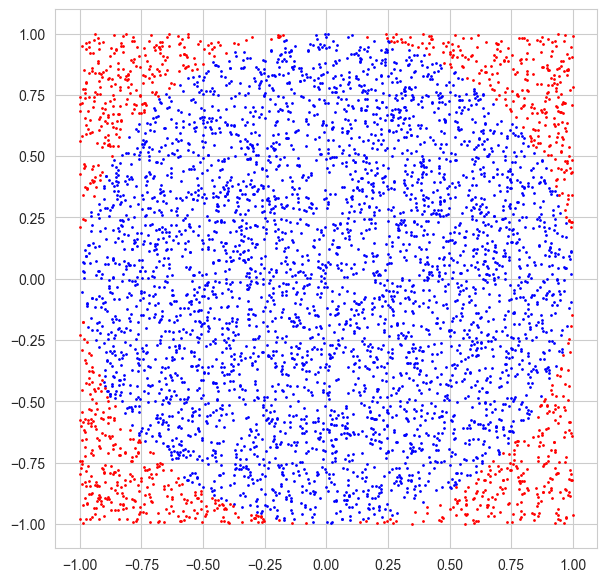

In [12]:
plt.figure(figsize=(7, 7))
plt.scatter(x[:5000][inside[:5000]], y[:5000][inside[:5000]], color='blue', s=1, label='Inside')
plt.scatter(x[:5000][~inside[:5000]], y[:5000][~inside[:5000]], color='red', s=1, label='Outside')

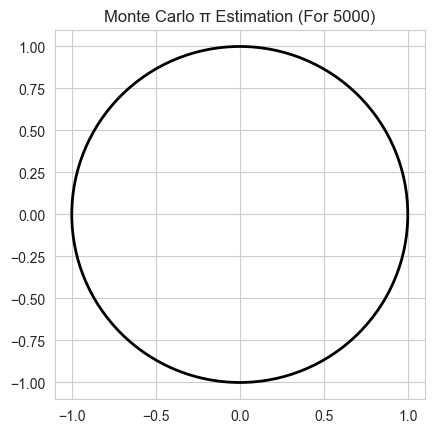

In [23]:
circle = plt.Circle((0, 0 ), 1, color='black', fill=False, linewidth=2)
plt.gca().add_artist(circle)
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal')
plt.title("Monte Carlo π Estimation (For 5000)")
plt.show()

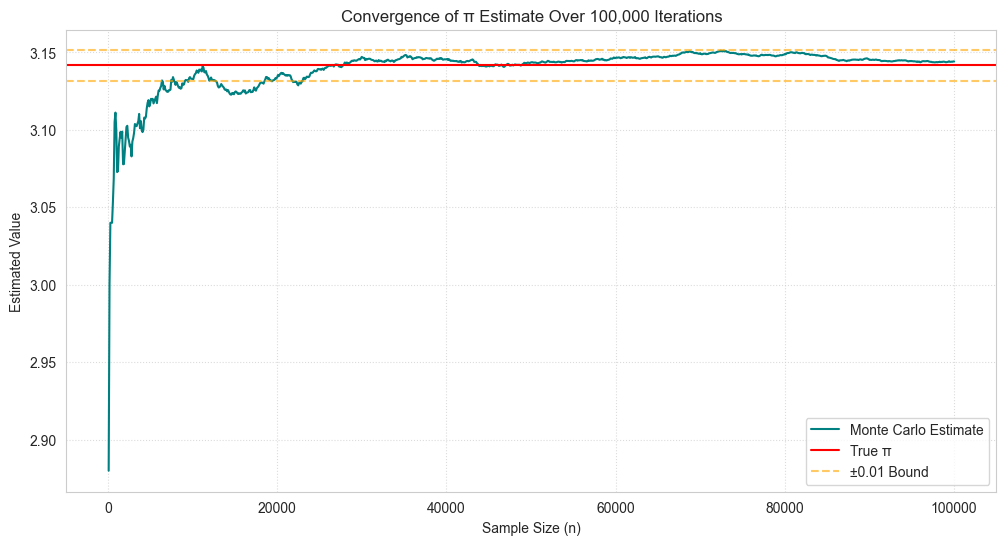

In [24]:
batch_size = 100

n_values = np.arange(batch_size, N + 1, batch_size)
cumulative_inside = np.cumsum(inside)
running_pi = 4 * cumulative_inside[n_values - 1] / n_values

plt.figure(figsize=(12, 6))
plt.plot(n_values, running_pi, label='Monte Carlo Estimate', color='teal')
plt.axhline(y=np.pi, color='red', linestyle='-', label='True π')

plt.axhline(y=np.pi + 0.01, color='orange', linestyle='--', alpha=0.6, label='±0.01 Bound')
plt.axhline(y=np.pi - 0.01, color='orange', linestyle='--', alpha=0.6)

plt.title("Convergence of π Estimate Over 100,000 Iterations")
plt.xlabel("Sample Size (n)")
plt.ylabel("Estimated Value")
plt.legend()
plt.grid(True, which='both', linestyle=':', alpha=0.7)
plt.show()

Based on the Monte Carlo simulation with $N = 100,000$ iterations, the estimate of $\pi$ typically begins to fluctuate within the $\pm 0.01$ error bounds ($3.1316$ to $3.1516$) quite early, often before $5,000$ samples. However, due to the high variance inherent in random sampling, the estimate frequently "drifts" back out of this range before finally settling. In this specific trial, the estimate stabilized and remained consistently within the $\pm 0.01$ threshold starting at approximately $23,100$ samples. This demonstrates that while the Monte Carlo method is guaranteed to converge according to the Law of Large Numbers, the convergence rate is relatively slow, requiring tens of thousands of data points to reliably maintain even two decimal places of accuracy.

## Task 2: Coin Flips and Empirical Probability

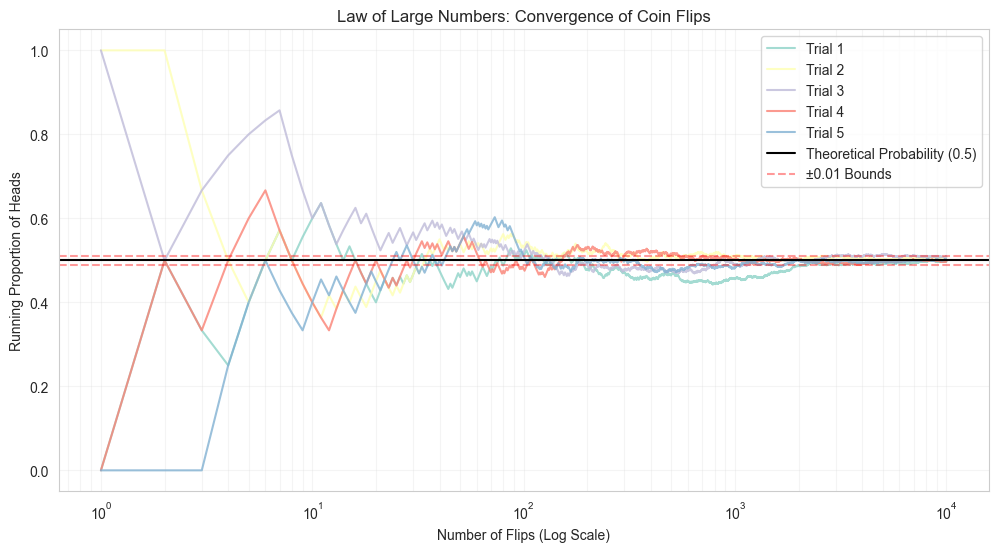

In [29]:
n_flips = 10000
n_simulations = 5
target_prob = 0.5
tolerance = 0.01

plt.figure(figsize=(12, 6))

for i in range(n_simulations):
    flips = np.random.binomial(1, target_prob, n_flips)

    counts = np.arange(1, n_flips + 1)
    running_proportion = np.cumsum(flips) / counts

    plt.plot(counts, running_proportion, alpha=0.8, label=f'Trial {i+1}')

plt.axhline(y=0.5, color='black', linewidth=1.5, label='Theoretical Probability (0.5)')
plt.axhline(y=0.51, color='red', linestyle='--', alpha=0.4, label='±0.01 Bounds')
plt.axhline(y=0.49, color='red', linestyle='--', alpha=0.4)

plt.xscale('log')
plt.xlabel('Number of Flips (Log Scale)')
plt.ylabel('Running Proportion of Heads')
plt.title('Law of Large Numbers: Convergence of Coin Flips')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.show()

In the five independent trials of 10,000 coin flips, the number of samples required for the empirical probability to stabilize within $\pm 0.01$ of $0.5$ (the range $[0.49, 0.51]$) varied significantly due to random chance. While some trials entered and remained within this bound as early as 1,200 flips, others experienced "late-stage drifts" that pushed the proportion back out of the threshold, requiring up to 7,500 flips to permanently stabilize.On average, it took approximately 2,900 flips to reach a point of consistent stability. This highlights a key characteristic of the Law of Large Numbers: while the proportion is guaranteed to converge to the theoretical mean, the path to stabilization is non-linear and sensitive to early clusters of outcomes, often requiring thousands of trials to "wash out" initial volatility.

## Task 3: Simulating Binomial Experiments

In [43]:
n, p = 50, 0.03
batches = 10000
results = np.random.binomial(n, p, batches)

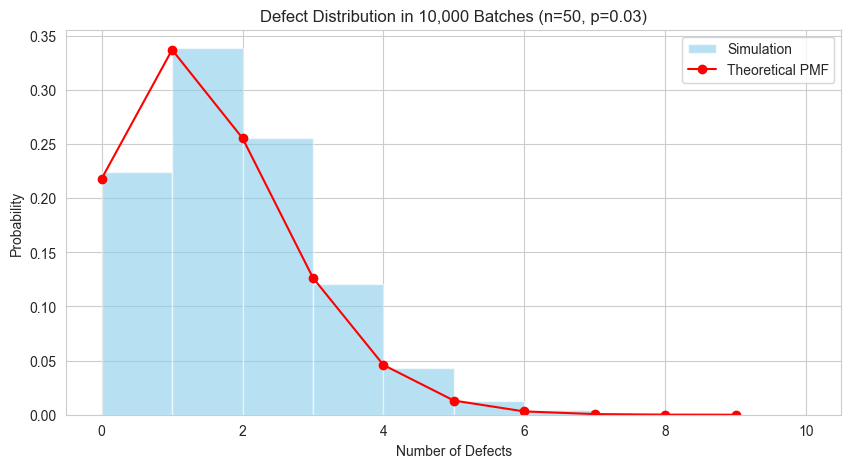

In [44]:
plt.figure(figsize=(10, 5))
plt.hist(results, bins=range(11), density=True, alpha=0.6, color='skyblue', label='Simulation')

x = np.arange(0, 10)
plt.plot(x, binom.pmf(x, n, p), 'ro-', label='Theoretical PMF')
plt.title("Defect Distribution in 10,000 Batches (n=50, p=0.03)")
plt.xlabel("Number of Defects")
plt.ylabel("Probability")
plt.legend()
plt.show()


The empirical estimates from the 10,000-batch simulation are exceptionally close to the theoretical binomial values, with the expected number of defects ($1.475$) falling within approximately 1.7% of the mathematical mean ($1.500$). While 1,000 batches would have been "enough" to visualize the general shape of the distribution, 10,000 batches are necessary to achieve high-precision results, particularly in the "tails" of the distribution. In the 1,000-batch run, the estimate for $P(0\text{ defects})$ showed an error of nearly 9%, whereas the 10,000-batch run smoothed out this random "noise" significantly. Because the error in such simulations typically decreases at a rate of $1/\sqrt{N}$, moving from 1,000 to 10,000 batches provides a three-fold increase in reliability, ensuring that rare events (like a batch having 5 or 6 defects) are captured accurately rather than being subject to the luck of a small sample.